In [1]:
## -- Check for 3rd party libraries --
try:
    import xgboost as xgb
    import shap, plotly
    from skrub import TableVectorizer
    from pytabkit import TabM_D_Regressor
except:
    %pip install -qq pytabkit skrub shap plotly xgboost==3.1.0
    import xgboost as xgb
    import shap, plotly
    from skrub import TableVectorizer
    from pytabkit import TabM_D_Regressor

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.0/364.0 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 499.4/499.4 kB 15.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
!pip show xgboost

Name: xgboost
Version: 3.1.0
Summary: XGBoost Python Package
Home-page: 
Author: 
Author-email: Hyunsu Cho <chohyu01@cs.washington.edu>, Jiaming Yuan <jm.yuan@outlook.com>
License: Apache-2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: numpy, nvidia-nccl-cu12, scipy
Required-by: TPOT


In [3]:
## -- Device-Agnostic for GPU --
import torch
print(f"ℹ️ Running on Cuda: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    get_ipython().run_line_magic('load_ext', 'cudf.pandas')
    get_ipython().run_line_magic('load_ext', 'cuml.accel')
    from cuml.preprocessing import TargetEncoder as cuTE
else:
    pass

ℹ️ Running on Cuda: False


In [4]:
## -- System dependencies --
import sys, os, gc

## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
from time import time, sleep
from tqdm.notebook import tqdm
from itertools import combinations, product

## -- Machine Learning --
import sklearn
from sklearn.linear_model import (
            LinearRegression,
            ElasticNetCV,
            LassoCV,
            RidgeCV,
            BayesianRidge,
)
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import mean_squared_error, PredictionErrorDisplay

import warnings

In [5]:
## -- Global Settings --
# sklearn.set_config(transform_output="pandas")
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
plt.style.use("ggplot")
# sns.set_style("whitegrid")
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
PALETTE = ['c', 'r', 'orange']

## -- Set Global Seed --
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

COLOR = '\033[32m'
RESET = '\033[0m'

In [6]:
### Load Data ###
PATH = '/kaggle/input/playground-series-s6e1/'
submit = pd.read_csv(PATH+'sample_submission.csv')
train = pd.read_csv(PATH+'train.csv').drop('id', axis=1)
test = pd.read_csv(PATH+'test.csv').drop('id', axis=1)

TARGET = train.columns[-1]
NUMS = test.select_dtypes(include='number').columns.tolist()
CATS = test.select_dtypes(exclude='number').columns.tolist()
BASE = NUMS + CATS

print(f"Data loaded")

Data loaded


In [7]:
# ## -- os.walk: Deep search with subfolders --
# def dataloader(filepath):    
#     train = pd.DataFrame()
#     test = pd.DataFrame()
    
#     # print("Loading .npy: ", end="")
#     # for (root, dirs, files) in os.walk(filepath):
#     #     for i, file in enumerate(sorted(files), 1):
#     #         if i%5 == 0: print(f"{i}%.. ", end="")
#     #         if file.endswith(".npy") and "train" in file:
#     #             train_path = np.load(os.path.join(root, file))
#     #             train = pd.concat([train, pd.Series(train_path, name=file[6:-4])], axis=1)
#     #         elif file.endswith(".npy") and "test" in file:
#     #             test_path = np.load(os.path.join(root, file))
#     #             test = pd.concat([test, pd.Series(test_path, name=file[5:-4])], axis=1)
#     # print()
#     print("Loading .parquet files: ", end="")
#     for (root, dirs, files) in os.walk(filepath):
#         for i, file in enumerate(sorted(files), 1):
#             if i%5 == 0: print(f"{i}%.. ", end="")
#             if file.endswith(".parquet") and "train" in file:
#                 train_path = os.path.join(root, file)
#                 train = pd.concat([train, pd.read_parquet(train_path)], axis=1)
#             elif file.endswith(".parquet") and "test" in file:
#                 test_path = os.path.join(root, file)
#                 test = pd.concat([test, pd.read_parquet(test_path)], axis=1)
#     print()
#     print(f"Total train models: {len(train.columns)} || Shape: {train.shape}")
#     print(f"Total test models : {len(test.columns)} || Shape: {test.shape}")
#     print()
    

#     return train, test

In [8]:
# PATHS = [
#     '/kaggle/input/ps6e1-per-feature-ag',
#     # '/kaggle/input/ps6e1-autogluon-trainorig',
#     # '/kaggle/input/ps6e1-lr-gbdt-nn-trainorig',
# ]

# ## -- Load and collect dfs --
# all_dfs = []

# for p in PATHS:
#     output = dataloader(p)
#     all_dfs.append(output)

# ## -- Concat datasets --
# ext_train = pd.DataFrame()
# ext_test = pd.DataFrame()

# for a, b in all_dfs:
#     ext_train = pd.concat([ext_train, a], axis=1)
#     ext_test = pd.concat([ext_test, b], axis=1)

# print('Loaded data shape:', ext_train.shape, ext_test.shape)

# ## -- Drop weighted autogluon models --
# for c in ext_train.columns:
#     if 'L2' in c or 'L3' in c:
#         ext_train.drop([c], axis=1, inplace=True)
#         ext_test.drop([c], axis=1, inplace=True)

# BASE = ext_train.columns.tolist()

# ## -- Check for missing values --
# ext_train.isna().sum().sum(), ext_test.isna().sum().sum()

In [9]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.style.background_gradient()

,age,study_hours,class_attendance,sleep_hours,gender,course,internet_access,sleep_quality,study_method,facility_rating,exam_difficulty
Train,8,792,617,66,3,7,2,3,5,3,3
Test,8,786,604,64,3,7,2,3,5,3,3


## FEATURE ENGINEERING

In [10]:
# # ## -- Create 'meta' feature --
# # ## -- https://www.kaggle.com/competitions/playground-series-s6e1/discussion/665915
# # def meta_feature(df):
# #     formula = (
# #         6 * df.study_hours + \
# #         0.35 * df.class_attendance + \
# #         1.5 * df.sleep_hours + \
# #         5 * (df.sleep_quality=='good') + \
# #         -5 * (df.sleep_quality=='poor') + \
# #         10 * (df.study_method=='coaching') + \
# #         5 * (df.study_method=='mixed') + \
# #         2 * (df.study_method=='group study') + \
# #         1 * (df.study_method=='online videos') + \
# #         4 * (df.facility_rating=='high') + \
# #         -4 * (df.facility_rating=='low')
# #     )
# #     return formula

# # train['formula'] = meta_feature(train)
# # test['formula'] = meta_feature(test)
# # orig['formula'] = meta_feature(orig)

# ## -- Set ordinal mapping --
# ordinal_maps = {
#     "internet_access": {"no":0, "yes":1},
#     "gender": {"male":0, "female":1, "other":2},
#     "sleep_quality": {"poor":0, "average":1, "good":2},
#     "facility_rating": {"low":0, "medium":1, "high":2},
#     "exam_difficulty": {"easy":0, "moderate":1, "hard":2},
#     "course": {"ba":0, "b.sc":1, "diploma":2, "b.tech":3, "b.com":4, "bca":5, "bba":6},
#     "study_method": {"self-study":0, "online videos":1, "group study":2, "mixed":3, "coaching":4},
# }

# for c in CATS:
#     train[c] = train[c].map(ordinal_maps[c]).fillna(-1)
#     test[c] = test[c].map(ordinal_maps[c]).fillna(-1)

# print("Categories encoded")

In [11]:
def feature_preprocess(df):
    df_temp = df.copy()

    df_temp['study_hours_squared'] = df_temp['study_hours'] ** 2
    df_temp['study_hours_cubed'] = df_temp['study_hours'] ** 3
    df_temp['class_attendance_squared'] = df_temp['class_attendance'] ** 2
    df_temp['sleep_hours_squared'] = df_temp['sleep_hours'] ** 2
    df_temp['age_squared'] = df_temp['age'] ** 2

    # df_temp['log_study_hours'] = np.log1p(df_temp['study_hours'])
    # df_temp['log_class_attendance'] = np.log1p(df_temp['class_attendance'])
    # df_temp['log_sleep_hours'] = np.log1p(df_temp['sleep_hours'])
    # df_temp['sqrt_study_hours'] = np.sqrt(df_temp['study_hours'])
    # df_temp['sqrt_class_attendance'] = np.sqrt(df_temp['class_attendance'])

    # Interaction features
    df_temp['study_hours_times_attendance'] = df_temp['study_hours'] * df_temp['class_attendance']
    df_temp['study_hours_times_sleep'] = df_temp['study_hours'] * df_temp['sleep_hours']
    df_temp['attendance_times_sleep'] = df_temp['class_attendance'] * df_temp['sleep_hours']

    # Ratio features (add small epsilon to avoid division by zero)
    eps = 1e-6
    df_temp['study_hours_over_sleep'] = df_temp['study_hours'] / (df_temp['sleep_hours'] + eps)
    df_temp['attendance_over_sleep'] = df_temp['class_attendance'] / (df_temp['sleep_hours'] + eps)

    # Feature by: Vladimir Demidov
    # https://www.kaggle.com/competitions/playground-series-s6e1/discussion/665915
    LUT = {
        'sleep_quality': {'good': 5, 'average': 0, 'poor': -5},
        'facility_rating': {'high': 4, 'medium': 0, 'low': -4},
        'study_method': {
            'coaching': 10,
            'mixed': 5,
            'group study': 2,
            'online videos': 1,
            'self-study': 0
        }
    }

    df_temp['formula'] = 6.0 * df_temp['study_hours'] + 0.35 * df_temp['class_attendance'] \
            + 1.5 * df_temp['sleep_hours'] \
            + df_temp['sleep_quality'].map(LUT['sleep_quality']) \
            + df_temp['study_method'].map(LUT['study_method']) \
            + df_temp['facility_rating'].map(LUT['facility_rating'])

    # Encode categorical variables to numeric ordinal values
    ordinal_maps = {
        "internet_access": {"no":0, "yes":1},
        "gender": {"male":0, "female":1, "other":2},
        "sleep_quality": {"poor":0, "average":1, "good":2},
        "facility_rating": {"low":0, "medium":1, "high":2},
        "exam_difficulty": {"easy":0, "moderate":1, "hard":2},
        "course": {"ba":0, "b.sc":1, "diploma":2, "b.tech":3, "b.com":4, "bca":5, "bba":6},
        "study_method": {"self-study":0, "online videos":1, "group study":2, "mixed":3, "coaching":4},
    }

    for c in CATS:
        df_temp[c] = df_temp[c].map(ordinal_maps[c]).fillna(-1)

    # Interaction between encoded categoricals and key numeric features
    df_temp['study_hours_times_sleep_quality'] = df_temp['study_hours'] * df_temp['sleep_quality']
    df_temp['attendance_times_facility'] = df_temp['class_attendance'] * df_temp['facility_rating']
    df_temp['sleep_hours_times_difficulty'] = df_temp['sleep_hours'] * df_temp['exam_difficulty']
    df_temp['age_times_study_hours'] = df_temp['age'] * df_temp['study_hours']
    df_temp['age_times_attendance'] = df_temp['age'] * df_temp['class_attendance']

    # Composite feature: learning efficiency
    df_temp['efficiency'] = (df_temp['study_hours'] * df_temp['class_attendance']) / (df_temp['sleep_hours'] + 1)
    df_temp["study_efficiency"] = df_temp["study_hours"] * (df_temp["class_attendance"] / 100.0)

    # Cyclic encoding
    for p in [12, 14, 365//2, 365, 365*2, 365*4]: #
        df_temp[f"study_hours_sin_{p}"] = np.sin(2 * np.pi * df_temp['study_hours'] / p)
        df_temp[f"class_attendance_sin_{p}"] = np.sin(2 * np.pi * df_temp['class_attendance'] / p)

    total_features = [c for c in df_temp.columns if c != TARGET]
    print(f'Feature Engineered: {len(total_features)}')

    return df_temp

train = feature_preprocess(train)
test = feature_preprocess(test)

train.head(3)

Feature Engineered: 41
Feature Engineered: 41


,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score,study_hours_squared,study_hours_cubed,class_attendance_squared,sleep_hours_squared,age_squared,study_hours_times_attendance,study_hours_times_sleep,attendance_times_sleep,study_hours_over_sleep,attendance_over_sleep,formula,study_hours_times_sleep_quality,attendance_times_facility,sleep_hours_times_difficulty,age_times_study_hours,age_times_attendance,efficiency,study_efficiency,study_hours_sin_12,class_attendance_sin_12,study_hours_sin_14,class_attendance_sin_14,study_hours_sin_182,class_attendance_sin_182,study_hours_sin_365,class_attendance_sin_365,study_hours_sin_730,class_attendance_sin_730,study_hours_sin_1460,class_attendance_sin_1460
0,21,1,1,7.91,98.8,0,4.9,1,1,0,0,78.3,62.5681,494.913671,9761.44,24.01,441,781.508,38.759,484.12,1.614285,20.163261,86.39,7.91,0.0,0.0,166.11,2074.8,132.458983,7.81508,-0.841511,0.994522,-0.397148,0.351375,0.269696,-0.266037,0.135744,0.991566,0.068030,0.751532,0.034035,0.412495
1,18,2,2,4.95,94.8,1,4.7,0,0,1,1,46.7,24.5025,121.287375,8987.04,22.09,324,469.260,23.265,445.56,1.053191,20.170208,64.93,0.00,94.8,4.7,89.10,1706.4,82.326316,4.69260,0.522499,-0.587785,0.795625,-0.990950,0.170058,-0.130811,0.085107,0.998133,0.042592,0.728379,0.021301,0.396753
2,20,1,1,4.68,92.6,1,5.8,0,4,2,1,99.0,21.9024,102.503232,8574.76,33.64,400,433.368,27.144,537.08,0.806896,15.965514,78.19,0.00,185.2,5.8,93.60,1852.0,63.730588,4.33368,0.637424,-0.978148,0.863018,-0.657939,0.160866,-0.055209,0.080475,0.999730,0.040270,0.715275,0.020139,0.388044


In [12]:
TOP_PREDICTORS = ['study_hours', 'class_attendance']
OTHER_PREDICTORS = [c for c in BASE if c not in TOP_PREDICTORS]

print('Feature sets defined!')

Feature sets defined!


In [13]:
## -- Extract Digits --
# DIGITS = []

# for col in tqdm(TOP_PREDICTORS+['sleep_hours']):
#     for d in range(-2, 4): # -2, 4
#         n = f'{col}_d{d}'
#         train[n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int32')
#         test[n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int32')
#         # orig[n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int32')

#         ## -- Drop constant features --
#         if train[n].nunique() < 2:
#             train.drop([n], axis=1, inplace=True)
#             test.drop([n],  axis=1, inplace=True)
#             # orig.drop([n],  axis=1, inplace=True)
#         else:
#             DIGITS.append(n)

# print(f'{len(DIGITS)} Feature DIGITS extracted.')
# print(train[DIGITS].nunique())

In [14]:
# DOUBLES = [c for c in BASE if train[c].dtype == 'float']
# ROUND = []

# for col in tqdm(TOP_PREDICTORS+['formula']):
#     for r in range(-2, 4): # -2, 4
#         n = f"{col}_r{r}"
#         train[n] = train[col].round(r)#.astype('int32')
#         test[n]  = test[col].round(r)#.astype('int32')
#         # orig[n]  = test[col].round(r).astype('int32')

#         ## -- Drop constant features --
#         if train[n].nunique() < 3:
#             train.drop([n], axis=1, inplace=True)
#             test.drop([n],  axis=1, inplace=True)
#             # orig.drop([n],  axis=1, inplace=True)
#         else:
#             ROUND.append(n)

# print(f'Total ROUNDed Features: {len(ROUND)}')
# print(train[ROUND].nunique())

In [15]:
# train.drop('exam_score', axis=1).corrwith(train['exam_score']).sort_values(ascending=False).head(30)

In [16]:
## -- Reduce data memory --
def reduce_memory(df):
    old_size = sys.getsizeof(df) / (1024*1024)
    for c in tqdm(df.columns, desc='Reducing memory...'):
        ## -- Downcast Integer type ---
        if df[c].dtype == np.int64: 
            if df[c].min() > np.iinfo(np.int32).min and df[c].max() < np.iinfo(np.int32).max:
                df[c] = df[c].astype(np.int32)
                # if df[c].min() > np.iinfo(np.int16).min and df[c].max() < np.iinfo(np.int16).max:
                #     df[c] = df[c].astype(np.int16)
                #     if df[c].min() > np.iinfo(np.int8).min and df[c].max() < np.iinfo(np.int8).max:
                #         df[c] = df[c].astype(np.int8)
        # ## -- Downcast Float type -----
        # elif df[c].dtype == np.float64:
        #     if df[c].min() > np.finfo(np.float32).min and df[c].max() < np.finfo(np.float32).max:
        #         df[c] = df[c].astype(np.float32)
                # if df[c].min() > np.finfo(np.float16).min and df[c].max() < np.finfo(np.float16).max:
                #     df[c] = df[c].astype(np.float16)

    new_size = sys.getsizeof(df) / (1024*1024)
    print(f"Size before process: {old_size:.1f}MB")
    print(f"Size after process : {new_size:.1f}MB\n")
    
    return df

train = reduce_memory(train)
test = reduce_memory(test)

gc.collect()

print(f"Data memory reduced!")

Reducing memory...:   0%|          | 0/42 [00:00<?, ?it/s]

Size before process: 201.9MB
Size after process : 180.2MB



Reducing memory...:   0%|          | 0/41 [00:00<?, ?it/s]

Size before process: 84.5MB
Size after process : 75.2MB

Data memory reduced!


In [17]:
FEATURES = [c for c in test.columns]
print('Total Features:', len(FEATURES))

train.head(3)

Total Features: 41


,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score,study_hours_squared,study_hours_cubed,class_attendance_squared,sleep_hours_squared,age_squared,study_hours_times_attendance,study_hours_times_sleep,attendance_times_sleep,study_hours_over_sleep,attendance_over_sleep,formula,study_hours_times_sleep_quality,attendance_times_facility,sleep_hours_times_difficulty,age_times_study_hours,age_times_attendance,efficiency,study_efficiency,study_hours_sin_12,class_attendance_sin_12,study_hours_sin_14,class_attendance_sin_14,study_hours_sin_182,class_attendance_sin_182,study_hours_sin_365,class_attendance_sin_365,study_hours_sin_730,class_attendance_sin_730,study_hours_sin_1460,class_attendance_sin_1460
0,21,1,1,7.91,98.8,0,4.9,1,1,0,0,78.3,62.5681,494.913671,9761.44,24.01,441,781.508,38.759,484.12,1.614285,20.163261,86.39,7.91,0.0,0.0,166.11,2074.8,132.458983,7.81508,-0.841511,0.994522,-0.397148,0.351375,0.269696,-0.266037,0.135744,0.991566,0.068030,0.751532,0.034035,0.412495
1,18,2,2,4.95,94.8,1,4.7,0,0,1,1,46.7,24.5025,121.287375,8987.04,22.09,324,469.260,23.265,445.56,1.053191,20.170208,64.93,0.00,94.8,4.7,89.10,1706.4,82.326316,4.69260,0.522499,-0.587785,0.795625,-0.990950,0.170058,-0.130811,0.085107,0.998133,0.042592,0.728379,0.021301,0.396753
2,20,1,1,4.68,92.6,1,5.8,0,4,2,1,99.0,21.9024,102.503232,8574.76,33.64,400,433.368,27.144,537.08,0.806896,15.965514,78.19,0.00,185.2,5.8,93.60,1852.0,63.730588,4.33368,0.637424,-0.978148,0.863018,-0.657939,0.160866,-0.055209,0.080475,0.999730,0.040270,0.715275,0.020139,0.388044


In [18]:
from sklearn.base import BaseEstimator, TransformerMixin

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique', 
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the 
        global mean. If 'auto', an empirical Bayes estimate is used.
        
    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping
        
        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)
        
        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)
            
        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)
        
        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]
            
            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'
                    
                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)
                    
                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()
                        
                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups
                        
                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)
                    
                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]
            
        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)
            
        return X_transformed

# ML TRAINING

In [19]:
# ## -- Prepare data for feature selection --
# ohe = OneHotEncoder(
#     handle_unknown='ignore',
#     sparse_output=False,
#     drop='first',
# ).fit(train[CATS+['age']]).set_output(transform='pandas')

# train_new = pd.concat([train.drop(CATS+['age'], axis=1), ohe.transform(train[CATS+['age']])], axis=1)
# test_new = pd.concat([test.drop(CATS+['age'], axis=1), ohe.transform(test[CATS+['age']])], axis=1)

# train_new.shape, test_new.shape

In [20]:
# FEATURES = [c for c in train_new.columns if c not in ['id', TARGET]]
# print('Total Features:', len(FEATURES))

# train_new.head(3)

In [21]:
xgb_params = {
    # 'sampling_method': 'gradient_based',
    # # ---------------------------------------
    # 'grow_policy': 'lossguide',
    # 'max_leaves': 128,
    'max_depth': 8,  # 0 if lossguide
    # ---------------------------------------
    'objective': 'reg:squarederror',
    'eval_metric': "rmse",
    'n_estimators': 10_000,
    'learning_rate': 0.01,
    'subsample': 0.8,
    'colsample_bytree': 0.35,
    'reg_lambda': 3.0,
    'reg_alpha': 1.5, # disable for lossguide
    'early_stopping_rounds': 200,
    'enable_categorical': True,
    # 'min_child_weight': 5,
    'random_state': SEED,
    'verbosity': 0,
    'n_jobs': os.cpu_count(),
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
}
tab_params = {
    'batch_size': 2048,
    'lr': 0.01,
    'n_epochs': 50,
    'patience': 4,
    'arch_type': 'tabm-mini',
    'random_state': SEED,
}
# tab_params = {
#     "verbosity": 0,
#     "arch_type": "tabm-mini-normal",
#     "tabm_k": 24, 
#     "num_emb_type": "pwl", 
#     "d_embedding": 8,
#     "batch_size": 256,
#     "lr": 1e-3, 
#     "n_epochs": 100, 
#     "dropout": 0.11, 
#     "d_block": 256, 
#     "n_blocks": 5, 
#     "patience": 4, 
#     "weight_decay": 1e-2, 
#     "device": "cuda",
#     "random_state": 42,
# }

In [22]:
## -- Define Models --
alphas_CV=(0.001, 0.01, 0.1, 1.0, 10.0, 100.0)
base_models = {
    'lr': LinearRegression(n_jobs=os.cpu_count()),
    'ridgeCV': RidgeCV(
        alphas=alphas_CV,
        cv=5,
        scoring='neg_root_mean_squared_error',
    ),
    'mlp': MLPRegressor(
        max_iter=1000,
        alpha=1e-2,
        tol=1e-5,
        random_state=SEED
    ),
    # 'xgb': xgb.XGBRegressor(**params),
    # 'tabm': TabM_D_Regressor(**tab_params),
    # 'bayes': BayesianRidge(max_iter=1000, tol=1e-5),
    # 'enetCV': ElasticNetCV(
    #     alphas=alphas_CV,
    #     cv=5,
    #     tol=1e-5,
    #     n_jobs=os.cpu_count(),
    #     random_state=SEED,
    # ),
    # 'lassoCV': LassoCV(
    #     alphas=alphas_CV,
    #     cv=5,
    #     tol=1e-5,
    #     n_jobs=os.cpu_count(),
    #     random_state=SEED,
    # ),
    # 'knn': KNeighborsRegressor(n_jobs=os.cpu_count()),
}

print(f"Base Models: {len(base_models)} -> ", base_models.keys())

Base Models: 3 ->  dict_keys(['lr', 'ridgeCV', 'mlp'])


In [23]:
## -- DEFINE TRAINING PARAMETERS --
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

y = train[TARGET].values
kf = KFold(n_splits=8, shuffle=True, random_state=SEED)

oof_final = pd.DataFrame()
test_final = pd.DataFrame()
all_scores = pd.Series()
all_models = []
    
## -- Initiate Training -- 
X = train[FEATURES]

for i, (name, model) in tqdm(
    enumerate(base_models.items()),
    total=len(base_models),
    desc='Training Models.'
):
    print(f"\n{COLOR}[{i+1}] {name} {'#'*10}{RESET}")
    tik = time()

    oof_preds  = np.zeros(len(train))
    test_preds = np.zeros(len(test))
    fold_RMSEs = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        X_test = test[FEATURES].copy()

        # ## -- TE Opt1. -> Using CUSTOM
        # TE = TargetEncoder(ROUND, cv=5, smooth='auto', aggs=['mean'], drop_original=True)
        # X_train = TE.fit_transform(X_train, pd.Series(y_train))
        # X_val   = TE.transform(X_val)
        # X_test  = TE.transform(X_test)

        a = [c for c in X_train.columns if c not in CATS+['age']] #+DIGITS
        b = [c for c in X_train.columns if 'TE_' in c]
        base_model = make_pipeline(
            make_column_transformer(
                (StandardScaler(), a+b), 
                (OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'), CATS+['age']), #+DIGITS
                remainder='passthrough',
                # n_jobs=os.cpu_count(),
            )
            , model).fit(X_train, y_train)
        
        X_train["feature_base"] = np.clip(base_model.predict(X_train), min(y), max(y))
        X_val["feature_base"]   = np.clip(base_model.predict(X_val), min(y), max(y))
        X_test["feature_base"]  = np.clip(base_model.predict(X_test), min(y), max(y))

        score_base = rmse(y_val, X_val["feature_base"])
        print(f"Fold {fold+1}/{kf.n_splits}:\nbase_model RMSE: {score_base:.5f}")

        combined = pd.concat([X_train, X_val, X_test])
        all_cats = CATS #+DIGITS
        for c in all_cats:
            combined[c] = combined[c].astype('category')
            
        X_train = combined.iloc[:len(X_train)]
        X_val   = combined.iloc[len(X_train):len(X_train)+len(X_val)]
        X_test  = combined.iloc[len(X_train)+len(X_val):]

        # m = 'tabM_over_' + name
        # model = TabM_D_Regressor(**tab_params),
        # model.fit(X_train, y_train, X_val, y_val) # cat_col_names=CATS+DIGITS
        
        m = 'xgb_over_' + name
        meta_model = xgb.XGBRegressor(**xgb_params)
        meta_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=500)
        
        y_pred = meta_model.predict(X_val)
        oof_preds[val_idx] = y_pred

        test_preds += meta_model.predict(X_test) / kf.n_splits

        ## -- RMSE for validation fold --
        meta_score = np.round(rmse(y_val, y_pred), 5)
        fold_RMSEs.append(meta_score)

        print(f"meta_model RMSE: {meta_score}\n")

    ## -- After all folds --
    overall_RMSE = np.round(rmse(y, oof_preds), 5)
    print(f"|{'-'*52}")
    print(f"| OOF RMSE: {overall_RMSE}")
    print(f"| AVG RMSE: {np.mean(fold_RMSEs):.5f} ± {np.std(fold_RMSEs):.5f}")
    print(f"|{'-'*52}")

    oof_final[m] = oof_preds
    test_final[m] = test_preds
    all_scores[m] = overall_RMSE
    all_models.append(meta_model)

    tok = time()
    tiktok = tok-tik
    print(f"Time: {tiktok:.2f} secs")

    gc.collect()

Training Models.:   0%|          | 0/3 [00:00<?, ?it/s]


[1] lr ##########
Fold 1/8:
base_model RMSE: 8.83969
[0]	validation_0-rmse:18.70685
[500]	validation_0-rmse:8.73693
[1000]	validation_0-rmse:8.69966
[1500]	validation_0-rmse:8.67935
[2000]	validation_0-rmse:8.66805
[2500]	validation_0-rmse:8.66055
[3000]	validation_0-rmse:8.65430
[3500]	validation_0-rmse:8.65057
[4000]	validation_0-rmse:8.64748
[4500]	validation_0-rmse:8.64592
[5000]	validation_0-rmse:8.64426
[5500]	validation_0-rmse:8.64374
[5787]	validation_0-rmse:8.64373
meta_model RMSE: 8.64361

Fold 2/8:
base_model RMSE: 8.89424
[0]	validation_0-rmse:18.70091
[500]	validation_0-rmse:8.79466
[1000]	validation_0-rmse:8.75526
[1500]	validation_0-rmse:8.73523
[2000]	validation_0-rmse:8.72278
[2500]	validation_0-rmse:8.71518
[3000]	validation_0-rmse:8.70956
[3500]	validation_0-rmse:8.70610
[4000]	validation_0-rmse:8.70319
[4500]	validation_0-rmse:8.70098
[5000]	validation_0-rmse:8.70086
[5013]	validation_0-rmse:8.70084
meta_model RMSE: 8.70063

Fold 3/8:
base_model RMSE: 8.88986
[0]	v

In [24]:
float(overall_RMSE)

8.69048

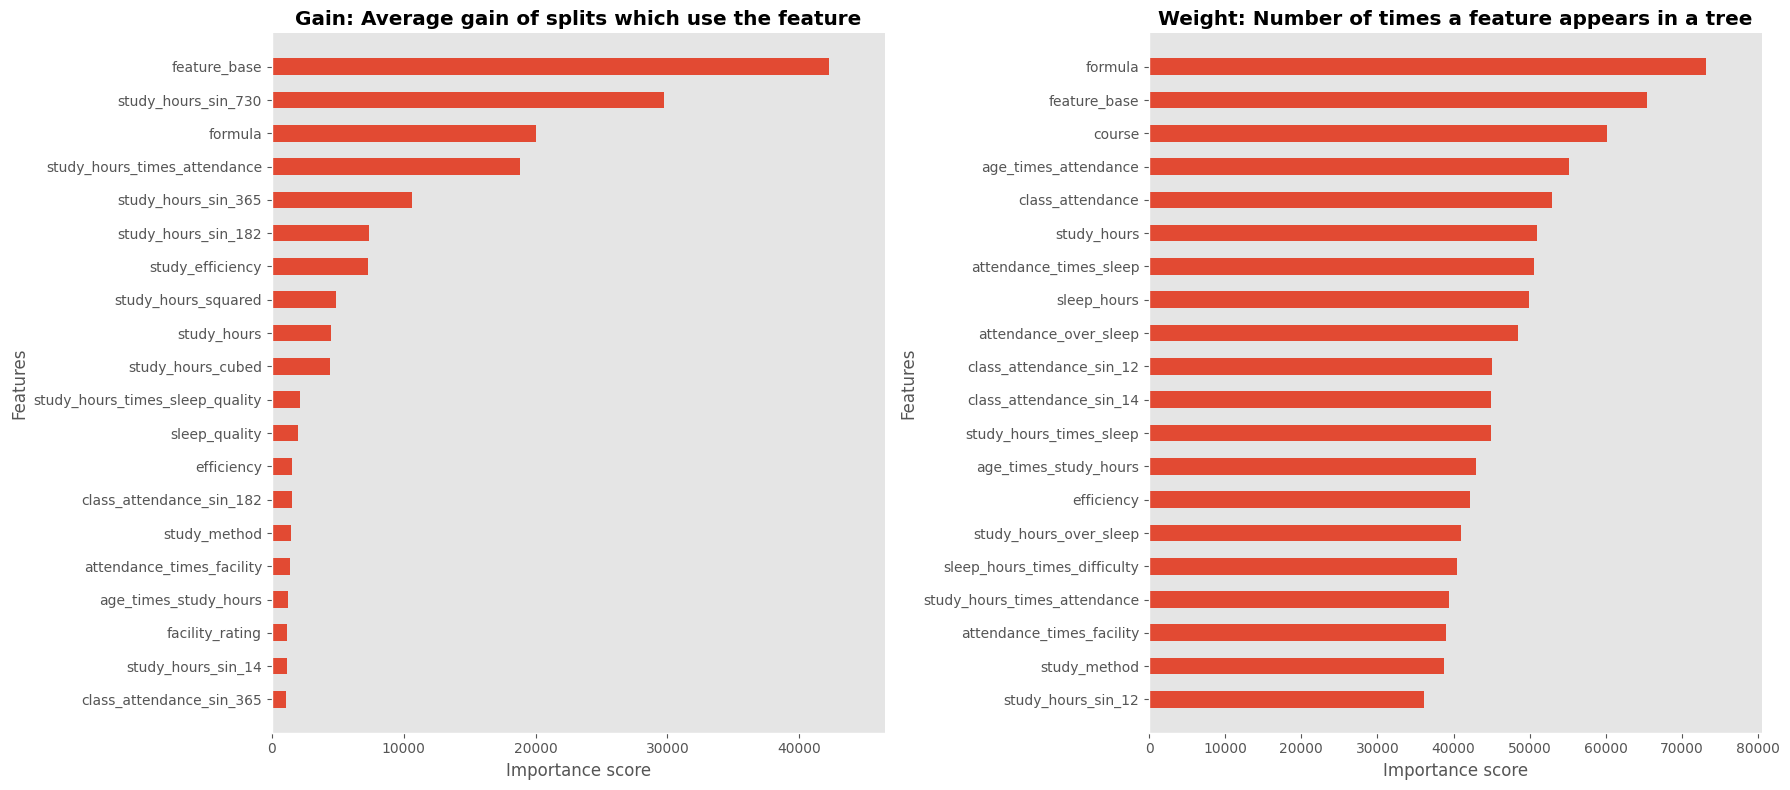

In [25]:
## -- plot_shap --
MAX = 20
_, axs = plt.subplots(1, 2, figsize=(18, 8))
xgb.plot_importance(
    all_models[0], ax=axs[0], height=0.5, max_num_features=MAX,
    importance_type='gain', show_values=False, grid=False
)
axs[0].set_title('Gain: Average gain of splits which use the feature', fontweight='bold')

xgb.plot_importance(
    all_models[0], ax=axs[1], height=0.5, max_num_features=MAX, 
    importance_type='weight', show_values=False, grid=False,
)
axs[1].set_title('Weight: Number of times a feature appears in a tree', fontweight='bold')
                 
for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
plt.tight_layout()
plt.show()

In [26]:
all_scores

xgb_over_lr         8.68274
xgb_over_ridgeCV    8.68298
xgb_over_mlp        8.69048
dtype: float64

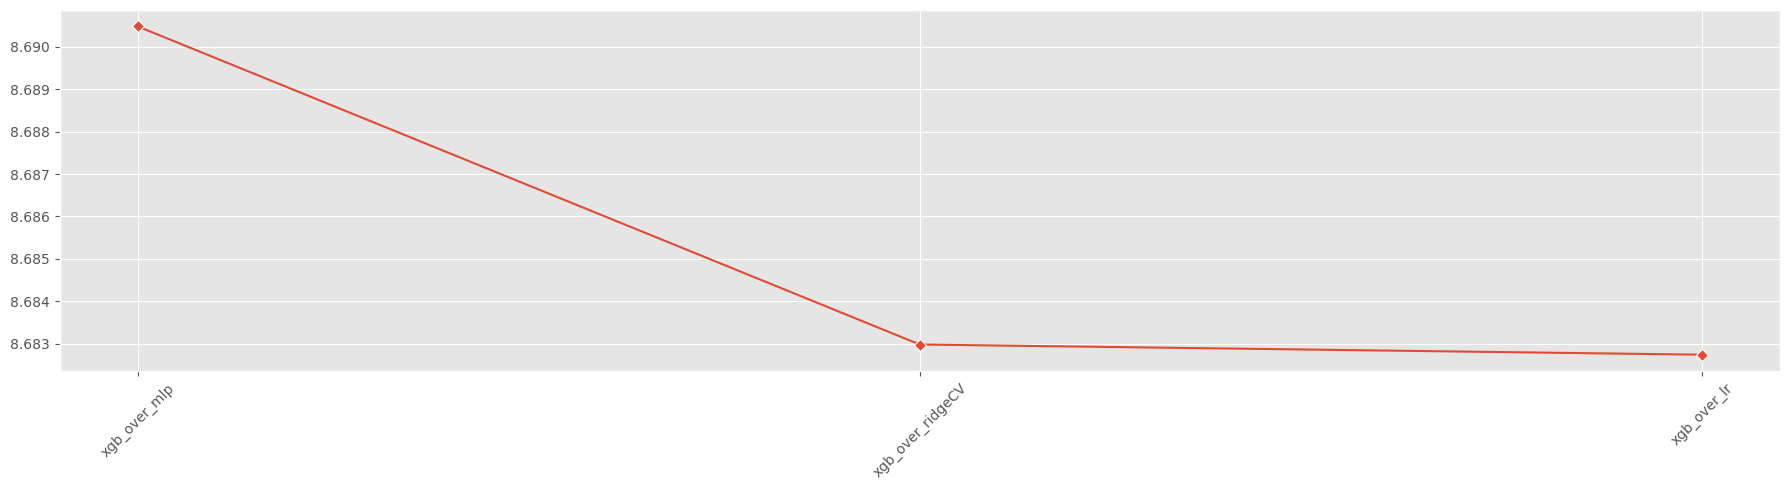

In [27]:
plt.figure(figsize=(18, 5))
sns.lineplot(all_scores.sort_values(ascending=False), marker='D')
plt.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [28]:
oof_final.head(3)

,xgb_over_lr,xgb_over_ridgeCV,xgb_over_mlp
0,87.516899,88.327248,86.565460
1,62.838547,63.109093,62.679665
2,74.393341,74.723068,75.265228


In [29]:
test_final.head(3)

,xgb_over_lr,xgb_over_ridgeCV,xgb_over_mlp
0,70.513012,70.597206,70.711028
1,70.852183,70.855190,70.723640
2,87.900454,88.064122,88.024510


# SUBMISSION

In [30]:
## -- Save OOF & PREDICTIONS --
n = f"xgb_over_LR_" + f"{overall_RMSE}".split('.')[1]
oof_final.to_parquet(f"oof_{n}.parquet", index=False)
test_final.to_parquet(f"pred_{n}.parquet", index=False)

## -- Submission file --
submit[TARGET] = np.clip(test_final.values, min(y), max(y))
submit.to_csv(f"submit_{n}.csv", index=False)
submit.head()

,id,exam_score
0,630000,70.513012
1,630001,70.852183
2,630002,87.900454
3,630003,55.500922
4,630004,47.138598
